In [1]:
# Install libraries (Colab ma already hova joiye)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


In [2]:
!pip install numpy==2.0.2 scikit-learn==1.6.1 xgboost==3.2.0 tensorflow==2.16.1 pandas joblib -q

ERROR: Cannot install numpy==2.0.2, scikit-learn==1.6.1, tensorflow==2.16.1 and xgboost==3.2.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [3]:
import numpy as np
import sklearn
import tensorflow as tf

print("NumPy:", np.__version__)
print("Sklearn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.0.2
Sklearn: 1.6.1
TensorFlow: 2.19.0


In [4]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/brain_stroke.csv")

In [6]:

print('Dataset loaded:', df.shape)


Dataset loaded: (9466, 11)


In [7]:
# Quick look
print(df.shape)
print(df.head())

(9466, 11)
   gender   age  hypertension  heart_disease ever_married work_type  \
0    Male  14.0             0              0           No   Private   
1    Male  67.0             1              0          Yes  Govt_job   
2  Female  49.0             0              0          Yes   Private   
3  Female  75.3             1              1          Yes  Govt_job   
4    Male  50.4             1              1          Yes  Govt_job   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban              72.88  26.5     never smoked       0  
1          Urban             249.80  33.0           smokes       1  
2          Urban              60.91  29.9     never smoked       1  
3          Urban             184.68  32.4  formerly smoked       1  
4          Urban             263.76  37.3  formerly smoked       1  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9466 entries, 0 to 9465
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9466 non-null   object 
 1   age                9466 non-null   float64
 2   hypertension       9466 non-null   int64  
 3   heart_disease      9466 non-null   int64  
 4   ever_married       9466 non-null   object 
 5   work_type          9466 non-null   object 
 6   Residence_type     9466 non-null   object 
 7   avg_glucose_level  9466 non-null   float64
 8   bmi                9466 non-null   float64
 9   smoking_status     9466 non-null   object 
 10  stroke             9466 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 813.6+ KB
None


In [9]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,9466.000000,9466.000000,9466.000000,9466.000000,9466.000000,9466.000000
mean,54.052654,0.431544,0.358124,153.343936,32.804205,0.500000
std,20.883527,0.495318,0.479474,65.032104,7.861260,0.500026
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,43.000000,0.000000,0.000000,90.300000,27.500000,0.000000
50%,58.250000,0.000000,0.000000,153.450000,32.300000,0.500000
75%,70.000000,1.000000,1.000000,210.737500,39.000000,1.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [10]:
# Count missing values
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [11]:
df["stroke"].value_counts()

,count
stroke,
0,4733
1,4733


In [12]:
# Example imputation
df['bmi'].fillna(df['bmi'].median(), inplace=True)
df['smoking_status'].fillna("Unknown", inplace=True)


/tmp/ipykernel_462/2505043351.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)
/tmp/ipykernel_462/2505043351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [13]:
df["work_type"].unique()

array(['Private', 'Govt_job', 'Self-employed', 'children'], dtype=object)

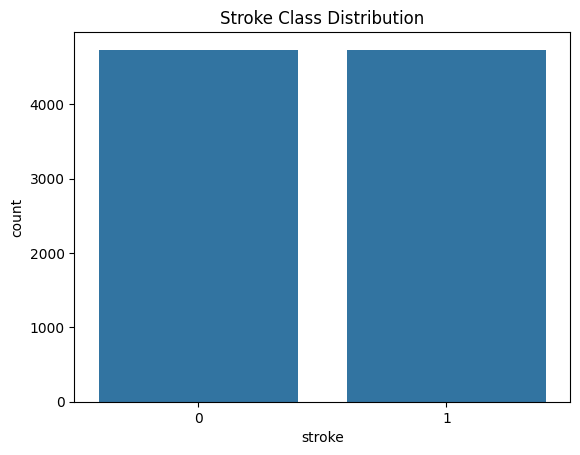

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='stroke', data=df)
plt.title("Stroke Class Distribution")
plt.show()



In [15]:
# ── Class Distribution check ─────────────────────────────
# Note: SMOTE niche Cell 20 ma train_test_split pachhi apply thase
print('Stroke class distribution:')
print(df['stroke'].value_counts())
print(f'\nImbalance ratio: {df["stroke"].value_counts()[0] / df["stroke"].value_counts()[1]:.1f}:1')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# class_weight='balanced' — imbalance handle karse
print('\nclass_weight balanced  ✅')


Stroke class distribution:
stroke
0    4733
1    4733
Name: count, dtype: int64

Imbalance ratio: 1.0:1

class_weight balanced  ✅


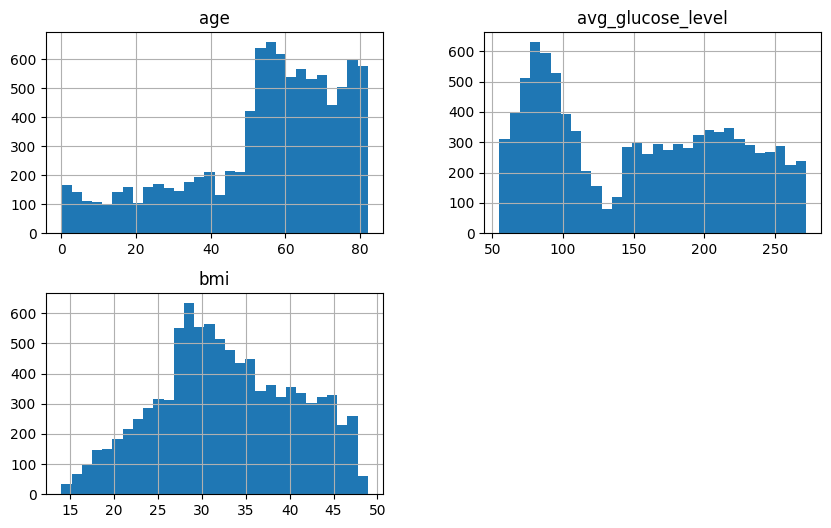

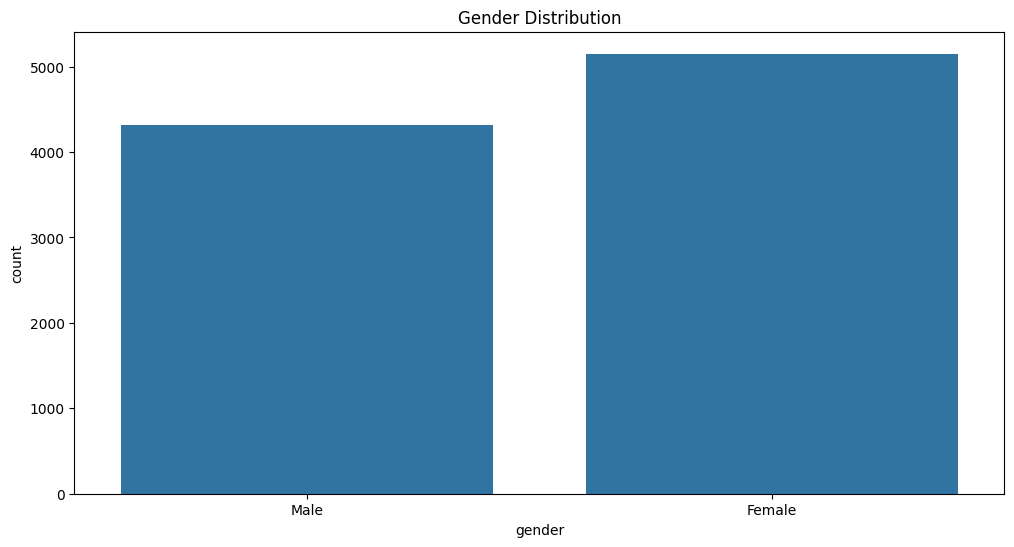

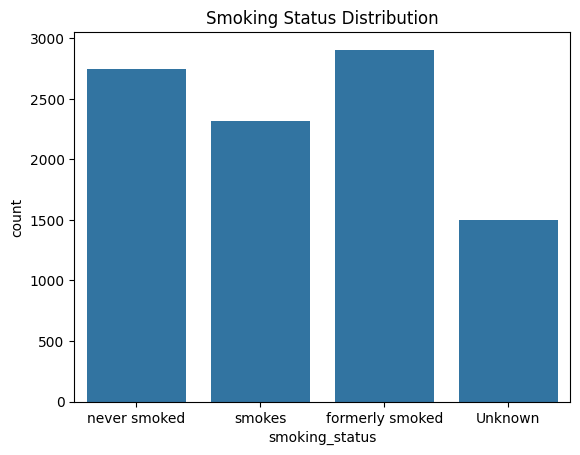

In [16]:
# Numeric features distribution
df[['age','avg_glucose_level','bmi']].hist(bins=30, figsize=(10,6))

# Categorical features distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

sns.countplot(x='smoking_status', data=df)
plt.title("Smoking Status Distribution")
plt.show()


<Axes: xlabel='stroke', ylabel='age'>

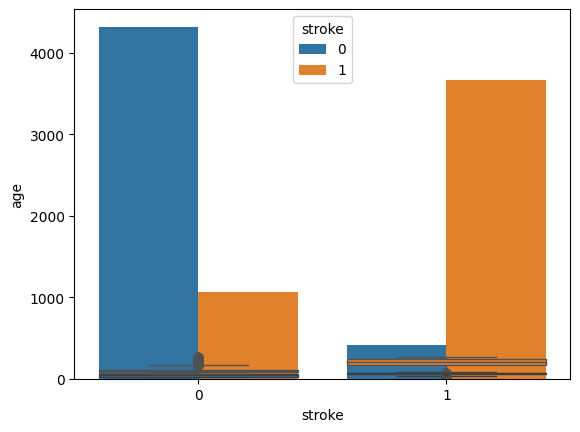

In [17]:
# Age vs Stroke
sns.boxplot(x='stroke', y='age', data=df)

# Glucose vs Stroke
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)

# Hypertension vs Stroke
sns.countplot(x='hypertension', hue='stroke', data=df)


In [18]:
# Average glucose level by stroke status
df.groupby('stroke')['avg_glucose_level'].mean()

# BMI by stroke status
df.groupby('stroke')['bmi'].mean()

# Hypertension vs stroke
pd.crosstab(df['hypertension'], df['stroke'])


stroke,0,1
hypertension,,
0,4320,1061
1,413,3672


In [19]:
# Only encode gender and smoking_status
# ever_married, work_type, Residence_type — HTML ma nathi, drop karya
df_encoded = pd.get_dummies(df, columns=['gender','smoking_status'], drop_first=True)
# Drop columns not used in HTML form
drop_cols = ['ever_married','work_type','Residence_type']
df_encoded = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])
df_encoded.head()


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,14.0,0,0,72.88,26.5,0,True,False,True,False
1,67.0,1,0,249.80,33.0,1,True,False,False,True
2,49.0,0,0,60.91,29.9,1,False,False,True,False
3,75.3,1,1,184.68,32.4,1,False,True,False,False
4,50.4,1,1,263.76,37.3,1,True,True,False,False


In [20]:
categorical_cols = ["gender", "smoking_status"]  # ever_married, work_type, Residence_type removed
numerical_cols = ["age", "avg_glucose_level", "bmi"]
binary_cols = ["hypertension", "heart_disease", "stroke"]

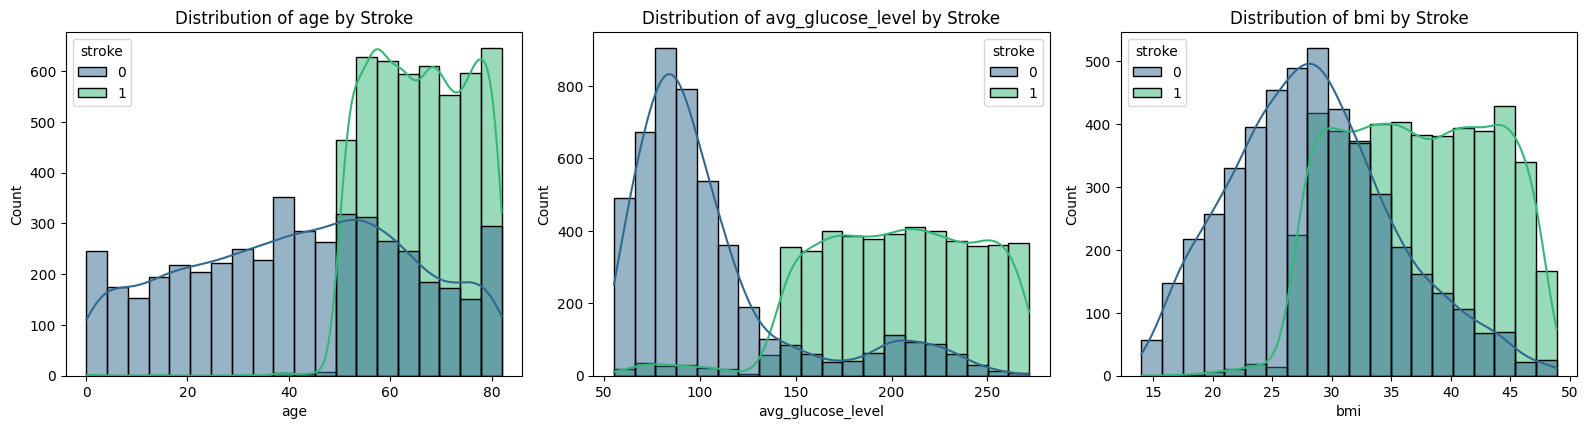

In [21]:
warnings.simplefilter(action="ignore", category=FutureWarning)

plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df, x=col, hue="stroke", kde=True, bins=20, palette="viridis", edgecolor="black")
    plt.title(f"Distribution of {col} by Stroke")

plt.tight_layout()
plt.show()

In [22]:
# Hypertension vs Heart disease vs Stroke
pd.crosstab([df['hypertension'], df['heart_disease']], df['stroke'], normalize='index') * 100


stroke                              0          1
hypertension heart_disease                      
0            0              91.135064   8.864936
             1              21.197605  78.802395
1            0              23.660131  76.339869
             1               1.996086  98.003914

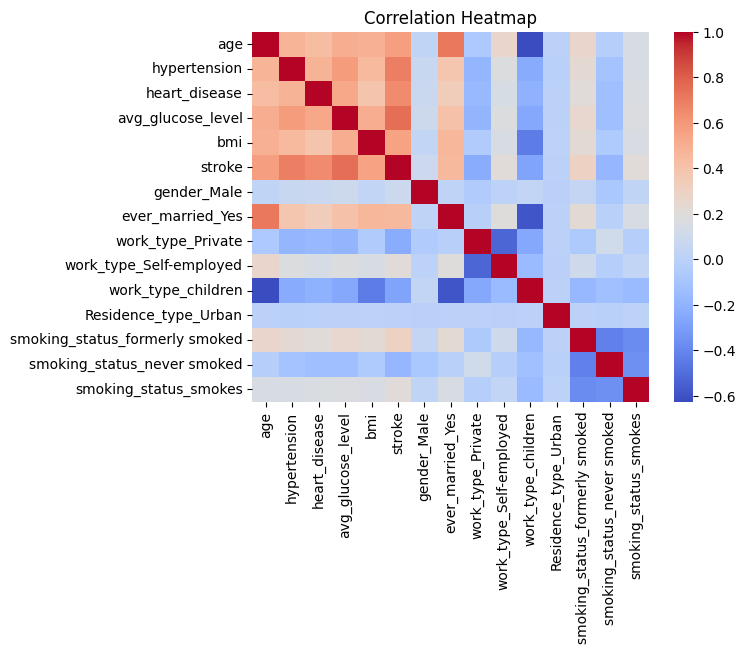

In [23]:
# Convert categorical columns to numeric
df_corr_temp = pd.get_dummies(df, drop_first=True)

# Now correlation works (df_encoded ne overwrite nahi kartu)
corr = df_corr_temp.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


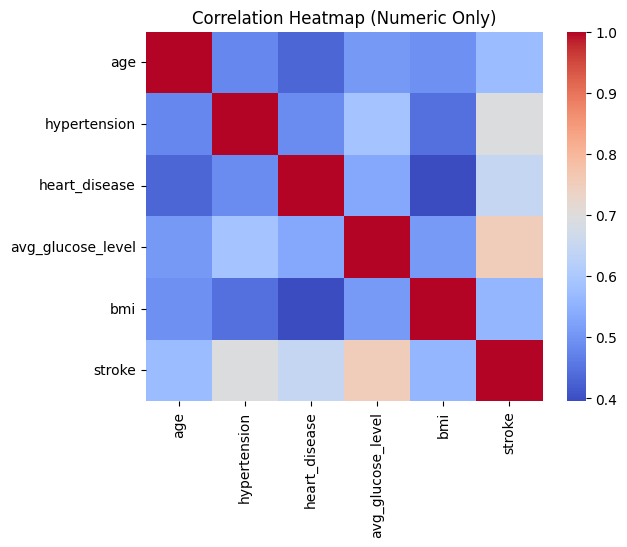

In [24]:
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()


In [25]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

# feature names save karo — selector mate zaroori
feature_names = list(X.columns)
print(f'Total features: {len(feature_names)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# StandardScaler — SVC mate zaroori
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE — scaled data par
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', Counter(y_train))
print('After  SMOTE:', Counter(y_train_res))


Total features: 9
Before SMOTE: Counter({0: 3786, 1: 3786})
After  SMOTE: Counter({0: 3786, 1: 3786})


In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier

# ── Feature Selection ─────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k="all")
X_train_sel = selector.fit_transform(X_train_res, y_train_res)
X_test_sel  = selector.transform(X_test_scaled)

selected_features = [feature_names[i] for i in selector.get_support(indices=True)]
print('Selected features:', selected_features)

# ── Strong Base Learners ──────────────────────────────────
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=2,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        scale_pos_weight=34,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    )),
    ('svc', SVC(
        probability=True,
        class_weight='balanced',
        kernel='rbf',
        C=1.0,
        random_state=42
    ))
]

# ── Stacking Classifier ───────────────────────────────────
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        C=0.5
    ),
    cv=5,
    stack_method='predict_proba'
)

stack_model.fit(X_train_sel, y_train_res)
print('Brain stacking model trained ✅')


Selected features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
Brain stacking model trained ✅


In [27]:
y_proba = stack_model.predict_proba(X_test_sel)[:, 1]
BEST_THRESHOLD = 0.15  # medical use — stroke detect karvanu important
y_pred_thresh = (y_proba >= BEST_THRESHOLD).astype(int)
print(f'Using threshold: {BEST_THRESHOLD}')


Using threshold: 0.15


--- Results with Threshold = 0.1 ---
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       947
           1       0.89      0.97      0.93       947

    accuracy                           0.93      1894
   macro avg       0.93      0.93      0.93      1894
weighted avg       0.93      0.93      0.93      1894

ROC-AUC (correct): 1.0


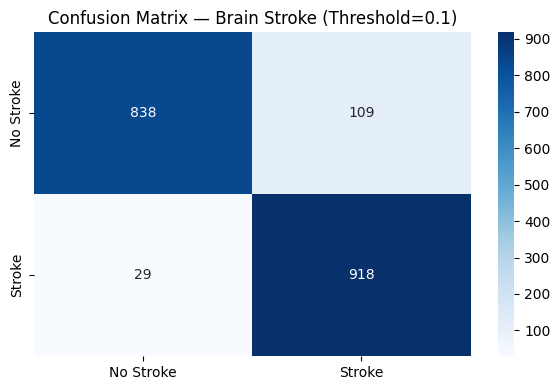

In [28]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fix 1: y_pred_thresh (threshold=0.3) use karo — not default y_pred
print("--- Results with Threshold = 0.1 ---")
print(classification_report(y_test, y_pred_thresh))

# Fix 2: ROC-AUC mate probability (y_proba) joie, not binary predictions
print("ROC-AUC (correct):", round(roc_auc_score(y_test, y_proba), 1))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'])
plt.title('Confusion Matrix — Brain Stroke (Threshold=0.1)')
plt.tight_layout()
plt.show()


In [29]:
# Threshold Comparison — best balance find karo
print('Threshold Analysis:')
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    from sklearn.metrics import f1_score, precision_score, recall_score
    y_t = (y_proba >= t).astype(int)
    print(f'  {t:.2f} | Precision: {precision_score(y_test, y_t):.2f} | '
          f'Recall: {recall_score(y_test, y_t):.2f} | '
          f'F1: {f1_score(y_test, y_t):.2f}')


Threshold Analysis:
  0.25 | Precision: 0.91 | Recall: 0.96 | F1: 0.94
  0.30 | Precision: 0.92 | Recall: 0.96 | F1: 0.94
  0.35 | Precision: 0.92 | Recall: 0.96 | F1: 0.94
  0.40 | Precision: 0.93 | Recall: 0.96 | F1: 0.94
  0.45 | Precision: 0.93 | Recall: 0.96 | F1: 0.95
  0.50 | Precision: 0.94 | Recall: 0.96 | F1: 0.95


## Cross-Validation & Feature Importance

In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(stack_model, X, y, cv=5, scoring='roc_auc')
print(f'Cross-validated ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Cross-validated ROC-AUC: 0.9857 ± 0.0018


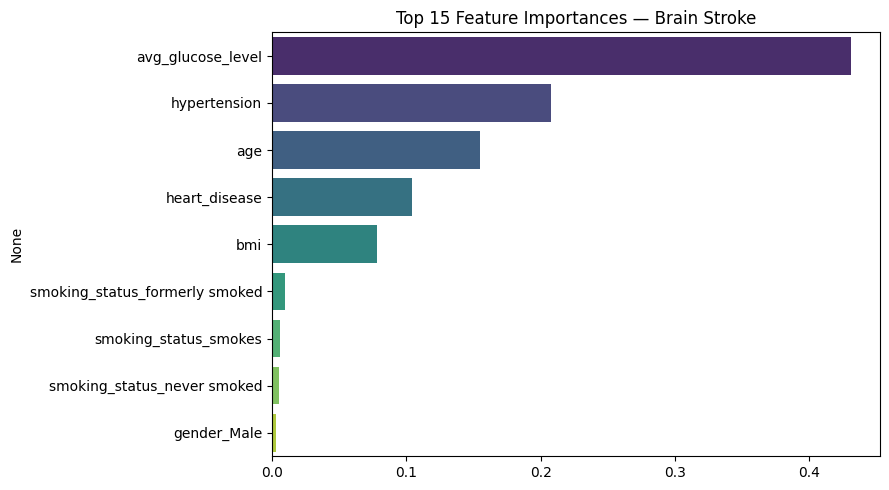

In [31]:
# Feature Importance from RF base learner
import pandas as pd

importances = stack_model.named_estimators_['rf'].feature_importances_
feat_df = pd.Series(importances, index=selected_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_df.values, y=feat_df.index, palette='viridis')
plt.title('Top 15 Feature Importances — Brain Stroke')
plt.tight_layout()
plt.show()


## Save Model (VitalsAI mate)

In [32]:
import joblib, os

# Local save
os.makedirs('models', exist_ok=True)
joblib.dump(stack_model,       'models/brain_ml_model.pkl')
joblib.dump(selected_features, 'models/brain_features.pkl')
joblib.dump(selector,          'models/brain_selector.pkl')
joblib.dump(scaler,            'models/brain_scaler.pkl')
print('Saved locally ✅')

# Google Drive save
try:
    os.makedirs('/content/drive/MyDrive/VitalsAI_models', exist_ok=True)
    joblib.dump(stack_model,       '/content/drive/MyDrive/VitalsAI_models/brain_ml_model.pkl')
    joblib.dump(selected_features, '/content/drive/MyDrive/VitalsAI_models/brain_features.pkl')
    joblib.dump(selector,          '/content/drive/MyDrive/VitalsAI_models/brain_selector.pkl')
    joblib.dump(scaler,            '/content/drive/MyDrive/VitalsAI_models/brain_scaler.pkl')
    print('Saved to Google Drive ✅')
except Exception as e:
    print(f'Drive save skipped: {e}')

print(f'\nTotal features : {len(feature_names)}')
print(f'Selected       : {selected_features}')
print('\nFiles to copy to VitalsAI/models/:')
for f in ['brain_ml_model.pkl','brain_features.pkl','brain_selector.pkl','brain_scaler.pkl']:
    print(f'  ✅ {f}')


Saved locally ✅
Saved to Google Drive ✅

Total features : 9
Selected       : ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

Files to copy to VitalsAI/models/:
  ✅ brain_ml_model.pkl
  ✅ brain_features.pkl
  ✅ brain_selector.pkl
  ✅ brain_scaler.pkl


In [33]:
# ── Prediction Function ───────────────────────────────────
def brain_risk_analyzer(model, selector, scaler, patient_df, threshold=0.15):
    scaled = scaler.transform(patient_df)
    sel    = selector.transform(scaled)
    prob   = model.predict_proba(sel)[:, 1][0]
    pred   = 1 if prob >= threshold else 0
    return pred, round(float(prob) * 100, 2)

# ── Test with X_test sample ───────────────────────────────
prob_test = stack_model.predict_proba(X_test_sel[[0]])[:, 1][0]
pred_test = 1 if prob_test >= BEST_THRESHOLD else 0

print('--- SAMPLE TEST ---')
print(f'Risk Probability : {round(prob_test*100, 2)}%')
print(f'Prediction       : {"Stroke Risk 🔴" if pred_test == 1 else "Low Risk 🟢"}')
print(f'Actual           : {"Stroke" if y_test.iloc[0] == 1 else "No Stroke"}')


--- SAMPLE TEST ---
Risk Probability : 1.78%
Prediction       : Low Risk 🟢
Actual           : No Stroke


In [34]:
# ── HIGH RISK Patient Test ────────────────────────────────
# Colab ma aa new cell ma paste karo (Cell 31 / last cell pachhi)

import pandas as pd

print("=" * 50)
print("  BRAIN STROKE — HIGH RISK TEST CASES")
print("=" * 50)

# Test cases — clearly high risk hova joie
test_cases = [
    {
        "label": "HIGH RISK — Elderly, Hypertension, Heart Disease",
        "age": 75,
        "hypertension": 1,
        "heart_disease": 1,
        "avg_glucose_level": 220.0,
        "bmi": 35.0,
        "gender_Male": 1,
        "smoking_status_formerly smoked": 1,
        "smoking_status_never smoked": 0,
        "smoking_status_smokes": 0,
    },
    {
        "label": "HIGH RISK — Middle aged, smoker, high glucose",
        "age": 60,
        "hypertension": 1,
        "heart_disease": 0,
        "avg_glucose_level": 200.0,
        "bmi": 32.0,
        "gender_Male": 0,
        "smoking_status_formerly smoked": 0,
        "smoking_status_never smoked": 0,
        "smoking_status_smokes": 1,
    },
    {
        "label": "LOW RISK — Young, healthy",
        "age": 28,
        "hypertension": 0,
        "heart_disease": 0,
        "avg_glucose_level": 80.0,
        "bmi": 22.0,
        "gender_Male": 1,
        "smoking_status_formerly smoked": 0,
        "smoking_status_never smoked": 1,
        "smoking_status_smokes": 0,
    },
    {
        "label": "YOUR FORM TEST — Age40, BMI23, Glucose90, HT+HD+FormerSmoke",
        "age": 40,
        "hypertension": 1,
        "heart_disease": 1,
        "avg_glucose_level": 90.0,
        "bmi": 23.0,
        "gender_Male": 1,
        "smoking_status_formerly smoked": 1,
        "smoking_status_never smoked": 0,
        "smoking_status_smokes": 0,
    },
]

THRESHOLD = 0.15

for tc in test_cases:
    label = tc.pop("label")
    patient_df = pd.DataFrame([tc]).reindex(columns=selected_features, fill_value=0)
    scaled = scaler.transform(patient_df)
    sel    = selector.transform(scaled)
    prob   = stack_model.predict_proba(sel)[:, 1][0]
    pred   = "🔴 STROKE RISK" if prob >= THRESHOLD else "🟢 Low Risk"
    print(f"\n{label}")
    print(f"  Probability : {round(prob*100, 2)}%")
    print(f"  Prediction  : {pred}")

print("\n" + "=" * 50)
print("  selected_features used:", selected_features)
print("=" * 50)


  BRAIN STROKE — HIGH RISK TEST CASES

HIGH RISK — Elderly, Hypertension, Heart Disease
  Probability : 96.88%
  Prediction  : 🔴 STROKE RISK

HIGH RISK — Middle aged, smoker, high glucose
  Probability : 94.36%
  Prediction  : 🔴 STROKE RISK

LOW RISK — Young, healthy
  Probability : 1.73%
  Prediction  : 🟢 Low Risk

YOUR FORM TEST — Age40, BMI23, Glucose90, HT+HD+FormerSmoke
  Probability : 2.9%
  Prediction  : 🟢 Low Risk

  selected_features used: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
